# Example 7: Benchmark ISOSIMpy against TracerLPM
In this example, we benchmark simulation results from ISOSIMpy against equivalent results obtained from TracerLPM. We consider the tracer input data given in Example 3 of the TracerLPM documentation [(Jurgens et al., 2012)](https://pubs.usgs.gov/publication/tm4F3). We generated simulation results using different model units in TracerLPM and compare those results against those obtained with ISOSIMpy.

In [1]:
import ISOSIMpy.model as ism
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from datetime import datetime
import pandas as pd
import seaborn as sns

## 1. Load Tracer Input Signal

In [2]:
# load input series
# this would be the tracer concentration in precipitation or recharge in a
# practical problem
file_name = "TracerLPM_benchmark_input_yearly.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float],
    encoding="utf-8",
    skip_header=1
)

timestamps = np.array([datetime.strptime(row[0], r"%Y") for row in data])
input_series = np.array([row[1] for row in data], dtype=float)

In [3]:
# load benchmark data
file_name = "TracerLPM_benchmark_simulations_1.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float, float, float, float],
    encoding="utf-8",
    skip_header=1
)

timestamps_benchmark = np.array([datetime.strptime(row[0], r"%Y") for row in data])
data_benchmark_1 = np.array([[row[1], row[2], row[3], row[4]] for row in data], dtype=float)

In [4]:
# load benchmark data case 2
file_name = "TracerLPM_benchmark_simulations_2.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float, float, float, float],
    encoding="utf-8",
    skip_header=1
)

data_benchmark_2 = np.array([[row[1], row[2], row[3], row[4]] for row in data], dtype=float)

In [5]:
# load benchmark data case 2
file_name = "TracerLPM_benchmark_simulations_3.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float, float, float, float],
    encoding="utf-8",
    skip_header=1
)

data_benchmark_3 = np.array([[row[1], row[2], row[3], row[4]] for row in data], dtype=float)

## 2. Get ISOSIMpy Results

### 2.1 Piston Flow

#### Case 1

In [6]:
# define list of result time series
pm_sims = []
pm_bms = []

In [7]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
pm_mtt_true = 15. # 15 years
m.add_unit(
    ism.PMUnit(mtt=pm_mtt_true),
    fraction=1., # 100 percent of the overall response
    prefix="pm"
)

# simulate
pm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_1[:, 0],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=pm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
pm_sims.append(sim)
pm_bms.append(bm)

In [8]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
pm_mtt_true = 20. # 20 years
m.add_unit(
    ism.PMUnit(mtt=pm_mtt_true),
    fraction=1., # 100 percent of the overall response
    prefix="pm"
)

# simulate
pm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_2[:, 0],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=pm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
pm_sims.append(sim)
pm_bms.append(bm)

In [9]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
pm_mtt_true = 30. # 20 years
m.add_unit(
    ism.PMUnit(mtt=pm_mtt_true),
    fraction=1., # 100 percent of the overall response
    prefix="pm"
)

# simulate
pm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_3[:, 0],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=pm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
pm_sims.append(sim)
pm_bms.append(bm)

### 2.2 Exponential Model

#### Case 1

In [10]:
# define list of result time series
em_sims = []
em_bms = []

In [11]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
em_mtt_true = 15. # 15 years
m.add_unit(
    ism.EMUnit(mtt=em_mtt_true),
    fraction=1., # 100 percent of the overall response
    prefix="em"
)

# simulate
em_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_1[:, 1],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=em_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
em_sims.append(sim)
em_bms.append(bm)

In [12]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
em_mtt_true = 20. # 20 years
m.add_unit(
    ism.EMUnit(mtt=em_mtt_true),
    fraction=1., # 100 percent of the overall response
    prefix="em"
)

# simulate
em_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_2[:, 1],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=em_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
em_sims.append(sim)
em_bms.append(bm)

In [13]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
em_mtt_true = 30. # 20 years
m.add_unit(
    ism.EMUnit(mtt=em_mtt_true),
    fraction=1., # 100 percent of the overall response
    prefix="em"
)

# simulate
em_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_3[:, 1],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=em_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
em_sims.append(sim)
em_bms.append(bm)

### 2.3 Exponential Piston Flow

#### Case 1

In [14]:
# define list of result time series
epm_sims = []
epm_bms = []

In [15]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
epm_mtt_true = 15. # 15 years
epm_eta_true = 0.5 + 1. # epm_ratio + 1
m.add_unit(
    ism.EPMUnit(mtt=epm_mtt_true, eta=epm_eta_true),
    fraction=1., # 100 percent of the overall response
    prefix="epm"
)

# simulate
epm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_1[:, 2],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=epm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
epm_sims.append(sim)
epm_bms.append(bm)

In [16]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
epm_mtt_true = 20. # 15 years
epm_eta_true = 0.7 + 1. # epm_ratio + 1
m.add_unit(
    ism.EPMUnit(mtt=epm_mtt_true, eta=epm_eta_true),
    fraction=1., # 100 percent of the overall response
    prefix="epm"
)

# simulate
epm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_2[:, 2],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=epm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
epm_sims.append(sim)
epm_bms.append(bm)

In [17]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
epm_mtt_true = 30. # 15 years
epm_eta_true = 0.8 + 1. # epm_ratio + 1
m.add_unit(
    ism.EPMUnit(mtt=epm_mtt_true, eta=epm_eta_true),
    fraction=1., # 100 percent of the overall response
    prefix="epm"
)

# simulate
epm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_3[:, 2],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=epm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
epm_sims.append(sim)
epm_bms.append(bm)

### 2.4 Dispersion Model

#### Case 1

In [18]:
# define list of result time series
dm_sims = []
dm_bms = []

In [19]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
dm_mtt_true = 15. # 15 years
dm_dp_true = 0.5
m.add_unit(
    ism.DMUnit(mtt=dm_mtt_true, DP=dm_dp_true),
    fraction=1., # 100 percent of the overall response
    prefix="dm"
)

# simulate
dm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_1[:, 3],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=dm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
dm_sims.append(sim)
dm_bms.append(bm)

In [20]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
dm_mtt_true = 20. # 15 years
dm_dp_true = 0.7
m.add_unit(
    ism.DMUnit(mtt=dm_mtt_true, DP=dm_dp_true),
    fraction=1., # 100 percent of the overall response
    prefix="dm"
)

# simulate
dm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_2[:, 3],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=dm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
dm_sims.append(sim)
dm_bms.append(bm)

In [21]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
dm_mtt_true = 30. # 15 years
dm_dp_true = 0.8
m.add_unit(
    ism.DMUnit(mtt=dm_mtt_true, DP=dm_dp_true),
    fraction=1., # 100 percent of the overall response
    prefix="dm"
)

# simulate
dm_sim = m.simulate()

# make pandas series
bm = pd.Series(
    data=data_benchmark_3[:, 3],
    index=timestamps_benchmark
)

sim = pd.Series(
    data=dm_sim,
    index=timestamps
).truncate(
    before=timestamps_benchmark[0],
    after=timestamps_benchmark[-1]
    )

# append to list
dm_sims.append(sim)
dm_bms.append(bm)

# Create Global Figures

Text(0.5, 1.0, 'Dist. of Errors')

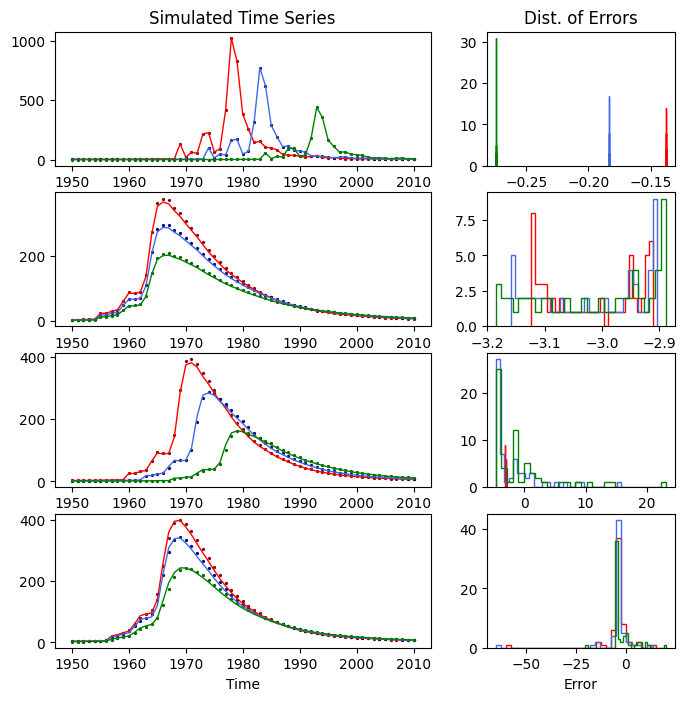

In [22]:
fig, ax = plt.subplots(
    4, 2,
    figsize=(8, 8),
    gridspec_kw={"width_ratios": [2, 1]},
    # sharex="col"
)

simulation_data = [pm_sims, em_sims, epm_sims, dm_sims]
benchmark_data = [pm_bms, em_bms, epm_bms, dm_bms]

colors_1 = ["red", "royalblue", "green"]
colors_2 = ["darkred", "navy", "darkgreen"]

# iterate over models / units
for i in range(4):
    unit_sims = simulation_data[i]
    unit_bms = benchmark_data[i]

    for j in range(len(unit_sims)):
        # plot simulation
        ax[i, 0].plot(
            unit_sims[j].index,
            unit_sims[j].values,
            c=colors_1[j],
            lw=1.
        )
        # plot benchmark
        ax[i, 0].scatter(
            unit_bms[j].index,
            unit_bms[j].values,
            c=colors_2[j],
            marker=".",
            s=7.
        )

        # plot errors
        errors = ((unit_sims[j].values - unit_bms[j].values) / unit_sims[j].values) * 100.
        # errors = (unit_sims[j].values - unit_bms[j].values)
        
        ax[i, 1].hist(
            errors,
            30,
            histtype="step",
            color=colors_1[j],
        )

# global settings
ax[-1, 0].set_xlabel("Time")
ax[0, 0].set_title("Simulated Time Series")
ax[-1, 1].set_xlabel("Error")
ax[0, 1].set_title("Dist. of Errors")

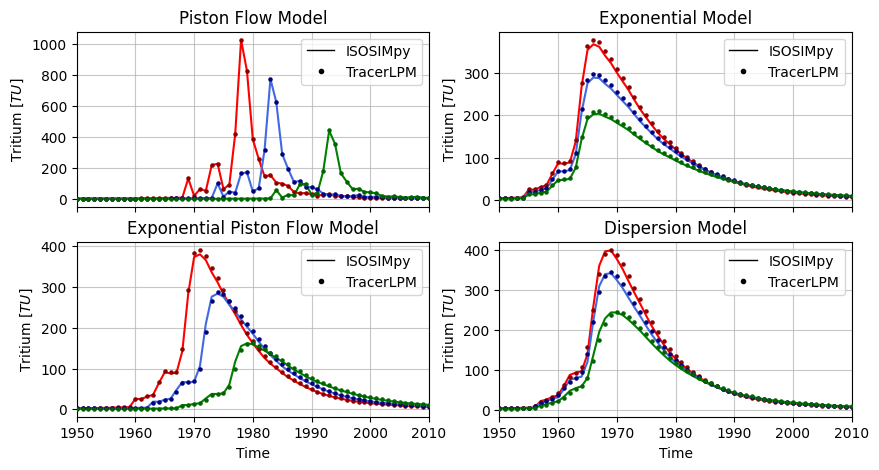

In [65]:
fig, ax = plt.subplots(
    2, 2,
    figsize=(10, 5),
    sharex="col",
    # sharey="row"
)

simulation_data = [pm_sims, em_sims, epm_sims, dm_sims]
benchmark_data = [pm_bms, em_bms, epm_bms, dm_bms]

names = ["Piston Flow Model", "Exponential Model", "Exponential Piston Flow Model", "Dispersion Model"]

colors_1 = ["red", "royalblue", "green"]
colors_2 = ["darkred", "navy", "darkgreen"]

# iterate over models / units
for i in range(4):
    unit_sims = simulation_data[i]
    unit_bms = benchmark_data[i]

    ax_ = ax.flatten()[i]

    for j in range(len(unit_sims)):
        # plot simulation
        ax_.plot(
            unit_sims[j].index,
            unit_sims[j].values,
            c=colors_1[j],
            lw=1.5,
            zorder=100
        )
        # plot benchmark
        ax_.scatter(
            unit_bms[j].index,
            unit_bms[j].values,
            c=colors_2[j],
            marker=".",
            s=20.,
            zorder=1000
        )
    # compose legend
    legend_elements = [
        Line2D([0], [0], color="k", lw=1, label="ISOSIMpy"),
        Line2D([0], [0], marker=".", color="w",
               markerfacecolor="k", markeredgecolor="k", label="TracerLPM")
               ]
    ax_.legend(handles=legend_elements, loc="upper right")
    ax_.set_title(names[i])
    ax_.set_ylabel(r"Tritium $ [TU] $")
    ax_.grid(True, zorder=0, alpha=0.7)
    ax_.set_xlim(unit_sims[j].index[0], unit_sims[j].index[-1])

    if i > 1:
        ax_.set_xlabel("Time")


## Calibration Benchmark

In [66]:
# input is already loaded

# load observations
file_name = "TracerLPM_benchmark_observations_6monthly.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float],
    encoding="utf-8",
    skip_header=1
)

obs_timestamps = np.array([datetime.strptime(row[0], r"%Y-%m") for row in data])
obs_series = np.array([[row[1]] for row in data], dtype=float)

In [67]:
# load input series with 6 month resolution
# this would be the tracer concentration in precipitation or recharge in a
# practical problem
file_name = "TracerLPM_benchmark_input_6monthly.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float],
    encoding="utf-8",
    skip_header=1
)

timestamps = np.array([datetime.strptime(row[0], r"%Y-%m") for row in data])
input_series = np.array([row[1] for row in data], dtype=float)

In [75]:
n_samples = 10000
burn_in = 50000
thin = 5
sigma = 1.
step_scale = .005 # .00005

### Mixing Ratio Case 1

In [137]:
# create model
t_half = 12.3 # years
lambda_ = np.log(2.0) / t_half

### define model (use the same structure / units as the true model)
# time step is 1 month
m = ism.Model(
    dt=.5,
    lambda_=lambda_,
    input_series=input_series,
    target_series=obs_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

pmfrac_1 = 0.05
emfrac_1 = 1 - pmfrac_1

# add a piston-flow unit
# define the true model parameters
pm_mtt_init = .5
m.add_unit(
    ism.PMUnit(mtt=pm_mtt_init),
    fraction=pmfrac_1,
    bounds=[(0., 10.)],
    prefix="pm"
)

# add a exponential-flow unit
# define the true model parameters
em_mtt_init = 2.5
m.add_unit(
    ism.EMUnit(mtt=em_mtt_init),
    fraction=emfrac_1,
    bounds=[(.1, 10.)],
    prefix="em"
)

# create a solver
solver = ism.Solver(m)
# # run MCMC
# res_1 = solver.mcmc_sample(
#     n_samples=n_samples, # effective samples after burn-in and thinning
#     burn_in=burn_in,
#     thin=thin,
#     rw_scale=step_scale, # 5 percent of the domain width of parameters
#     sigma=sigma,
#     random_state=None,
#     return_sim=True,
#     set_model_state=False
# )

# fig, ax = plt.subplots(2, 2, figsize=(10, 6))
# ax[0, 0].plot(res_1["samples"][:, 0])
# ax[0, 1].plot(res_1["samples"][:, 1])
# _ = ax[1, 0].hist(res_1["samples"][:, 0])   
# _ = ax[1, 1].hist(res_1["samples"][:, 1])

res_1_x, res_1 = solver.differential_evolution()

### Mixing Ratio Case 2

In [138]:
# create model
t_half = 12.3 # years
lambda_ = np.log(2.0) / t_half

### define model (use the same structure / units as the true model)
# time step is 1 month
m = ism.Model(
    dt=.5,
    lambda_=lambda_,
    input_series=input_series,
    target_series=obs_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

pmfrac_2 = 0.15
emfrac_2 = 1 - pmfrac_2

# add a piston-flow unit
# define the true model parameters
pm_mtt_init = .5
m.add_unit(
    ism.PMUnit(mtt=pm_mtt_init),
    fraction=pmfrac_2,
    bounds=[(0., 10.)],
    prefix="pm"
)

# add a exponential-flow unit
# define the true model parameters
em_mtt_init = 2.5
m.add_unit(
    ism.EMUnit(mtt=em_mtt_init),
    fraction=emfrac_2,
    bounds=[(.1, 10.)],
    prefix="em"
)

# create a solver
solver = ism.Solver(m)
# # run MCMC
# res_2 = solver.mcmc_sample(
#     n_samples=n_samples, # effective samples after burn-in and thinning
#     burn_in=burn_in,
#     thin=thin,
#     rw_scale=step_scale, # 5 percent of the domain width of parameters
#     sigma=sigma,
#     random_state=None,
#     return_sim=True,
#     set_model_state=False
# )

# fig, ax = plt.subplots(2, 2, figsize=(10, 6))
# ax[0, 0].plot(res_2["samples"][:, 0])
# ax[0, 1].plot(res_2["samples"][:, 1])
# _ = ax[1, 0].hist(res_2["samples"][:, 0])   
# _ = ax[1, 1].hist(res_2["samples"][:, 1])

res_2_x, res_2 = solver.differential_evolution()

### Mixing Ratio Case 3

In [139]:
# create model
t_half = 12.3 # years
lambda_ = np.log(2.0) / t_half

### define model (use the same structure / units as the true model)
# time step is 1 month
m = ism.Model(
    dt=0.5,
    lambda_=lambda_,
    input_series=input_series,
    target_series=obs_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

pmfrac_3 = 0.25
emfrac_3 = 1 - pmfrac_3

# add a piston-flow unit
# define the true model parameters
pm_mtt_init = .5
m.add_unit(
    ism.PMUnit(mtt=pm_mtt_init),
    fraction=pmfrac_3,
    bounds=[(0., 10.)],
    prefix="pm"
)

# add a exponential-flow unit
# define the true model parameters
em_mtt_init = 2.5
m.add_unit(
    ism.EMUnit(mtt=em_mtt_init),
    fraction=emfrac_3,
    bounds=[(.1, 10.)],
    prefix="em"
)

# create a solver
solver = ism.Solver(m)
# # run MCMC
# res_3 = solver.mcmc_sample(
#     n_samples=n_samples, # effective samples after burn-in and thinning
#     burn_in=burn_in,
#     thin=thin,
#     rw_scale=step_scale, # 5 percent of the domain width of parameters
#     sigma=sigma,
#     random_state=None,
#     return_sim=True,
#     set_model_state=False
# )

# fig, ax = plt.subplots(2, 2, figsize=(10, 6))
# ax[0, 0].plot(res_3["samples"][:, 0])
# ax[0, 1].plot(res_3["samples"][:, 1])
# _ = ax[1, 0].hist(res_3["samples"][:, 0])   
# _ = ax[1, 1].hist(res_3["samples"][:, 1])

res_3_x, res_3 = solver.differential_evolution()

### Mixing Ratio Case 4

In [140]:
# create model
t_half = 12.3 # years
lambda_ = np.log(2.0) / t_half

### define model (use the same structure / units as the true model)
# time step is 1 month
m = ism.Model(
    dt=0.5,
    lambda_=lambda_,
    input_series=input_series,
    target_series=obs_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

pmfrac_4 = 0.4
emfrac_4 = 1 - pmfrac_4

# add a piston-flow unit
# define the true model parameters
pm_mtt_init = .5
m.add_unit(
    ism.PMUnit(mtt=pm_mtt_init),
    fraction=pmfrac_4,
    bounds=[(0., 10.)],
    prefix="pm"
)

# add a exponential-flow unit
# define the true model parameters
em_mtt_init = 2.5
m.add_unit(
    ism.EMUnit(mtt=em_mtt_init),
    fraction=emfrac_4,
    bounds=[(.1, 10.)],
    prefix="em"
)

# create a solver
solver = ism.Solver(m)
# # run MCMC
# res_4 = solver.mcmc_sample(
#     n_samples=n_samples, # effective samples after burn-in and thinning
#     burn_in=burn_in,
#     thin=thin,
#     rw_scale=step_scale, # 5 percent of the domain width of parameters
#     sigma=sigma,
#     random_state=None,
#     return_sim=True,
#     set_model_state=False
# )

# fig, ax = plt.subplots(2, 2, figsize=(10, 6))
# ax[0, 0].plot(res_3["samples"][:, 0])
# ax[0, 1].plot(res_3["samples"][:, 1])
# _ = ax[1, 0].hist(res_3["samples"][:, 0])   
# _ = ax[1, 1].hist(res_3["samples"][:, 1])

res_4_x, res_4 = solver.differential_evolution()

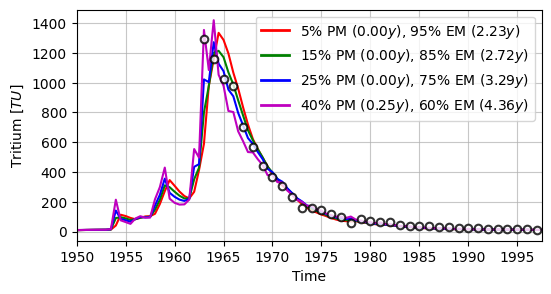

In [141]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

data_sims = [res_1, res_2, res_3, res_4]
colors = ["r", "g", "b", "m"]
start = 100
end = 196

for num, sims in enumerate(data_sims):
    ax.plot(
        timestamps[start:end],
        sims[start:end],
        c=colors[num]
    )

ax.scatter(
    obs_timestamps, obs_series,
    marker="o", facecolor="w",
    edgecolor="k", s=30,
    zorder=100, alpha=0.8,
    lw=1.5
)

ax.grid(True, alpha=0.7, zorder=0)
ax.set_xlim([timestamps[start], timestamps[end-1]])
ax.set_xlabel("Time")
ax.set_ylabel(r"Tritium $ [TU] $")

custom_lines = [Line2D([0], [0], color="r", lw=2),
                Line2D([0], [0], color="g", lw=2),
                Line2D([0], [0], color="b", lw=2),
                Line2D([0], [0], color="m", lw=2)]

ax.legend(custom_lines, [
    fr"{pmfrac_1:.0%} PM (${res_1_x["pm.mtt"]:.2f}y$), {emfrac_1:.0%} EM (${res_1_x["em.mtt"]:.2f}y$)",
    fr"{pmfrac_2:.0%} PM (${res_2_x["pm.mtt"]:.2f}y$), {emfrac_2:.0%} EM (${res_2_x["em.mtt"]:.2f}y$)",
    fr"{pmfrac_3:.0%} PM (${res_3_x["pm.mtt"]:.2f}y$), {emfrac_3:.0%} EM (${res_3_x["em.mtt"]:.2f}y$)",
    fr"{pmfrac_4:.0%} PM (${res_4_x["pm.mtt"]:.2f}y$), {emfrac_4:.0%} EM (${res_4_x["em.mtt"]:.2f}y$)",
])

# ax.set_yscale("log")

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

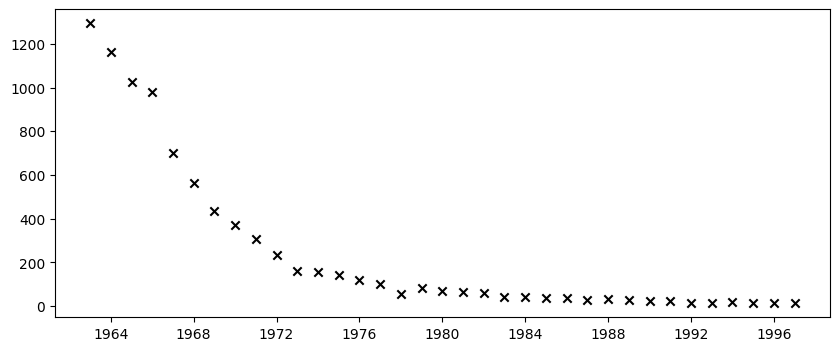

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.scatter(
    obs_timestamps, obs_series,
    marker="x", c="k"
)

data_sims = [res_1["sims"], res_2["sims"], res_3["sims"], res_4["sims"]]
colors = ["r", "g", "b", "m"]
start = 100
end = 196

for num, sims in enumerate(data_sims):
    ax.plot(
        timestamps[start:end],
        np.median(sims[:, start:end], axis=0),
        c=colors[num]
    )
    ax.fill_between(
        timestamps[start:end],
        np.percentile(sims[:, start:end], .00001, axis=0),
        np.percentile(sims[:, start:end], 99.99999, axis=0),
        color=colors[num],
        alpha=0.2
    )

ax.set_yscale("log")

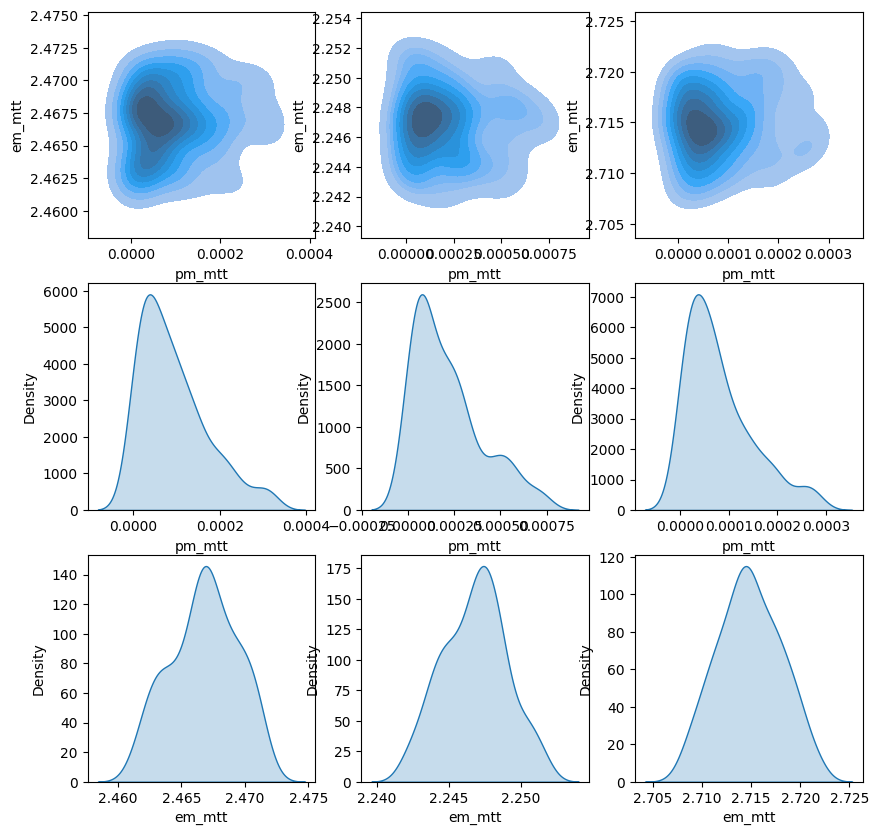

In [ ]:
df1 = pd.DataFrame(
    {"pm_mtt": res_1["samples"][::50, 0], "em_mtt": res_1["samples"][::50, 1]}
)

df2 = pd.DataFrame(
    {"pm_mtt": res_2["samples"][::50, 0], "em_mtt": res_2["samples"][::50, 1]}
)

df3 = pd.DataFrame(
    {"pm_mtt": res_3["samples"][::50, 0], "em_mtt": res_3["samples"][::50, 1]}
)

dfs = [df1, df2, df3]

fig, ax = plt.subplots(
    3, 3,
    figsize=(10, 10)
)

for i in range(3):
    df = dfs[i]

    # filter out values that are more than 2 standard deviations from the mean
    df = df[(df["pm_mtt"] < df["pm_mtt"].mean() + 2 * df["pm_mtt"].std()) & (df["pm_mtt"] > df["pm_mtt"].mean() - 2 * df["pm_mtt"].std())]
    df = df[(df["em_mtt"] < df["em_mtt"].mean() + 2 * df["em_mtt"].std()) & (df["em_mtt"] > df["em_mtt"].mean() - 2 * df["em_mtt"].std())]

    # plot joint kde in row 0
    sns.kdeplot(
        df,
        x="pm_mtt",
        y="em_mtt",
        ax=ax[0, i],
        fill=True
    )

    # plot marginal kde in rows 1 and 2
    sns.kdeplot(
        df,
        x="pm_mtt",
        ax=ax[1, i],
        fill=True
    )

    sns.kdeplot(
        df,
        x="em_mtt",
        ax=ax[2, i],
        fill=True
    )